# BESTEST Cases 600–695 summary

Annual, peak, solar, and native-ISO results for the conditioned 6XX family.

In [1]:
from pathlib import Path
import sys,pandas as pd,matplotlib.pyplot as plt
from IPython.display import display
cwd=Path.cwd().resolve()
root=next((p for p in (cwd,*cwd.parents) if (p/'validation/bestest_iso_reporting.py').is_file()),None)
if root is None: raise FileNotFoundError('Could not locate the BESTEST repository root')
sys.path.insert(0,str(root/'validation'))
from bestest_iso_case6xx_reporting import annual_tracks,comparison_table
CASES=('600','610','620','630','640','650','660','670','680','685','695')
metrics={case:pd.read_csv(root/'results'/'1_iso'/f'case{case}'/f'case{case}_metrics.csv') for case in CASES}

## Annual heating and cooling

Heating MWh                                      \
Run  Modelica native RClib-ISO + Modelica-resolved solar   
Case                                                       
600         4.657997                            4.582236   
610         4.783806                            4.714909   
620         4.823477                            4.768045   
630         5.096715                            5.052480   
640         2.898367                            2.566110   
650         0.000000                            0.000000   
660         3.898471                            3.844761   
670         7.381270                            7.302776   
680         2.646207                            2.577225   
685         5.063028                            4.982195   
695         3.146838                            3.074243   

                                Cooling MWh  \
Run  RClib-ISO native solar Modelica native   
Case                                          
600                5.502373        5.802666   
610                5.648637        4.602160   
620                5.059147        4.009000   
630                5.259892        2.953847   
640                3.749936        5.616459   
650                0.000000        4.820687   
660                4.681826        3.184404   
670                8.637256        4.975308   
680                3.226216        6.764384   
685                5.773615        8.650902   
695                3.613432        9.323000   

                                                                 
Run  RClib-ISO + Modelica-resolved solar RClib-ISO native solar  
Case                                                             
600                             5.727737               1.413772  
610                             4.536569               1.186934  
620                             3.967416               3.840018  
630                             2.923182               2.798867  
640                             5.430640               1.376850  
650                             4.801365               1.054494  
660                             3.134986               0.930337  
670                             4.902492               1.233579  
680                             6.696079               1.475017  
685                             8.584864               3.452811  
695                             9.265985               3.429614

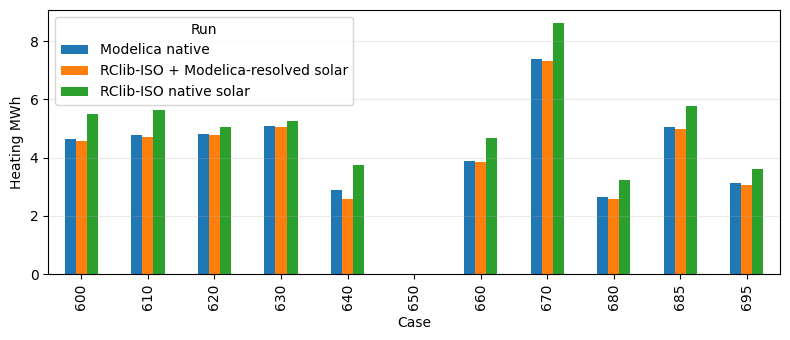

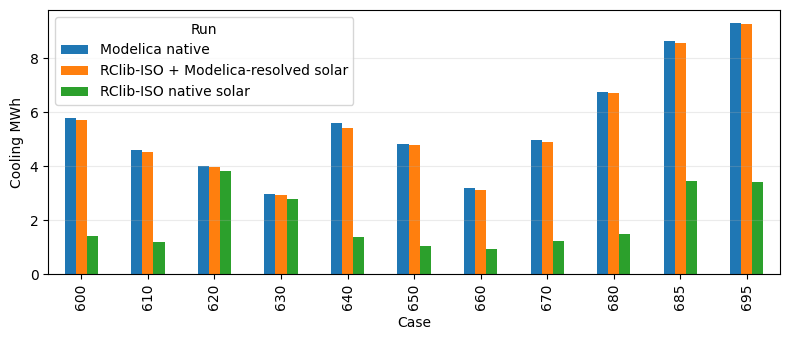

In [2]:
annual=pd.concat([annual_tracks(metrics[case]).assign(Case=case) for case in CASES]); display(annual.pivot(index='Case',columns='Run',values=['Heating MWh','Cooling MWh']))
for metric in ('Heating MWh','Cooling MWh'):
    fig,ax=plt.subplots(figsize=(8,3.5)); annual.pivot(index='Case',columns='Run',values=metric).plot(kind='bar',ax=ax); ax.set_ylabel(metric); ax.grid(axis='y',alpha=.25); fig.tight_layout(); plt.show()

## Controlled-forcing residuals and solar

In [3]:
residual=pd.concat([comparison_table(metrics[case],'controlled_modelica').assign(Case=case) for case in CASES]); display(residual.pivot(index='Case',columns='Metric',values='Difference %'))
solar=[]
for case in CASES:
    values=pd.read_csv(root/'results'/'1_iso'/f'case{case}'/f'case{case}_solar_comparison.csv').set_index('quantity').value
    solar.append({'Case':case,'Native solar MWh':values['native_rclib_zone_solar_MWh'],'Modelica solar MWh':values['modelica_resolved_zone_solar_MWh']})
display(pd.DataFrame(solar))

Metric,Annual cooling,Annual heating,Peak cooling,Peak heating
Case,,,,
600,-1.291280,-1.626474,-0.965498,2.598121
610,-1.425217,-1.440204,-1.818391,2.574102
620,-1.037266,-1.149214,-0.015808,2.562344
630,-1.038147,-0.867901,0.177639,2.558191
640,-3.308475,-11.463583,-1.422972,6.687364
650,-0.400820,NaN,-1.810430,NaN
660,-1.551858,-1.377708,-1.639800,2.562575
670,-1.463552,-1.063421,-1.687834,2.626561
680,-1.009774,-2.606835,-0.957722,2.684564


,Case,Native solar MWh,Modelica solar MWh
0,600,4.270377,12.112389
1,610,3.653750,10.247074
2,620,8.625660,9.349927
3,630,6.771119,7.340286
4,640,4.270377,12.112389
5,650,4.270377,12.112389
6,660,2.655251,7.208074
7,670,4.297211,13.507168
8,680,3.972237,11.562587
9,685,4.270377,12.112389


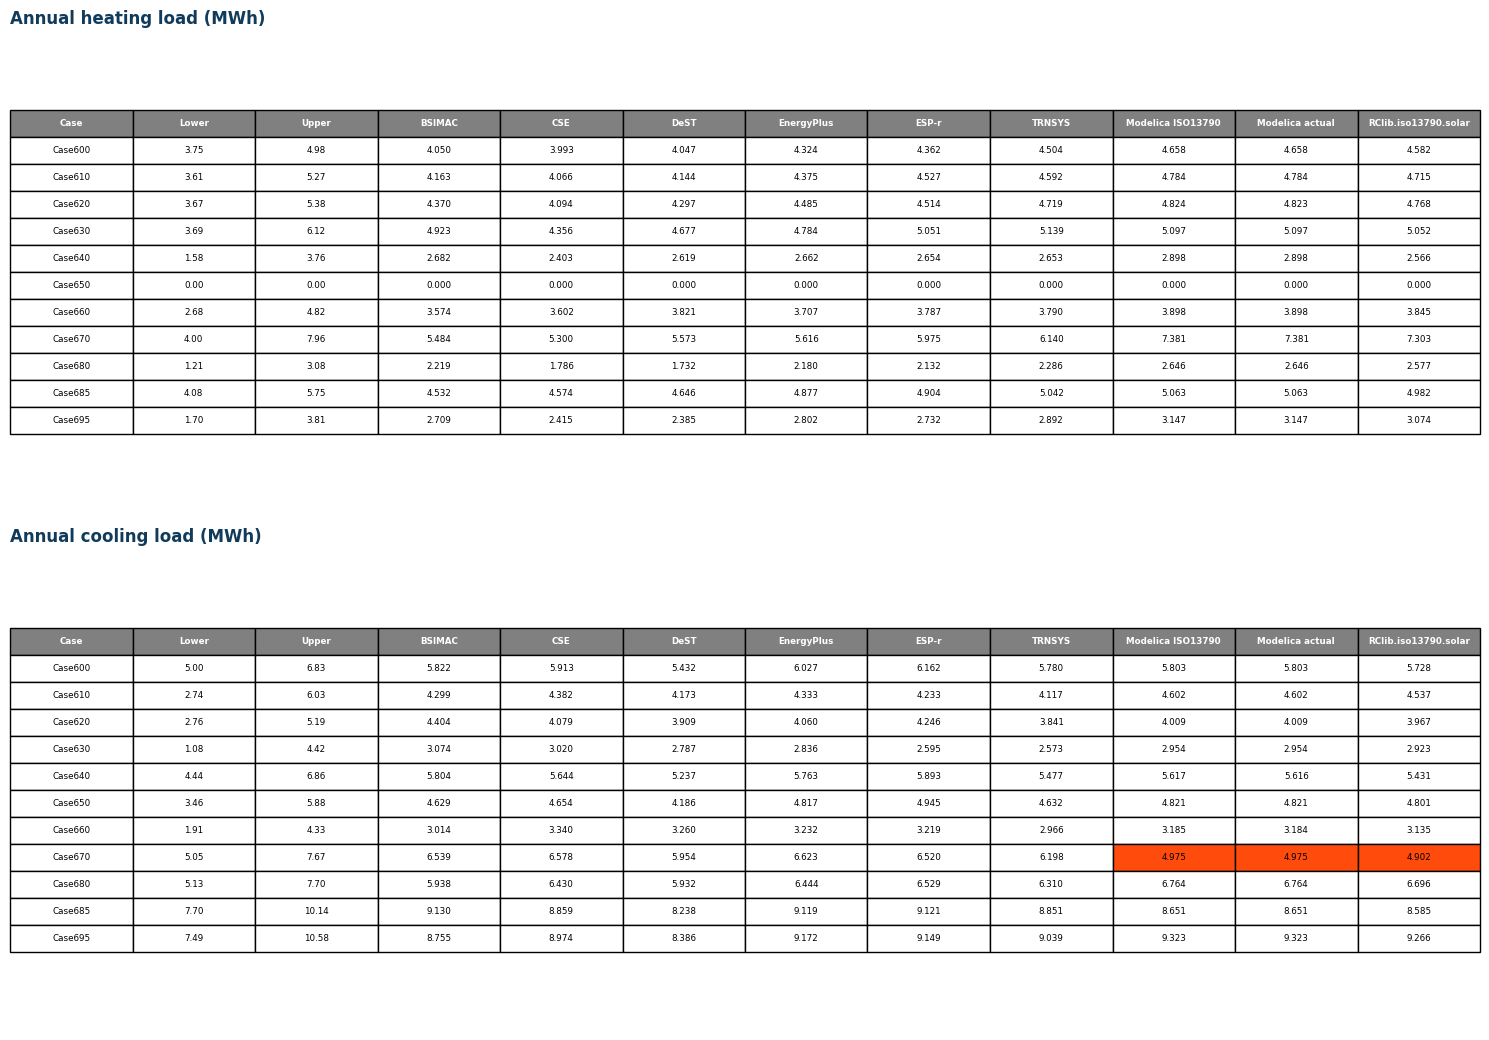

,case,metric,actual_modelica_MWh,native_iso_MWh,actual_modelica_status,native_iso_status
0,600,heating,4.657997,5.502373,PASS,FAIL
1,610,heating,4.783806,5.648637,PASS,FAIL
2,620,heating,4.823477,5.059147,PASS,PASS
3,630,heating,5.096715,5.259892,PASS,PASS
4,640,heating,2.898367,3.749936,PASS,PASS
5,650,heating,0.000000,0.000000,PASS,PASS
6,660,heating,3.898471,4.681826,PASS,PASS
7,670,heating,7.381270,8.637256,PASS,FAIL
8,680,heating,2.646207,3.226216,PASS,FAIL
9,685,heating,5.063028,5.773615,PASS,FAIL


In [4]:
from bestest_iso_plot_ashrae140_annual_matrix import build_summary, draw_table
matrix = build_summary()
family_cases = ('600', '610', '620', '630', '640', '650', '660', '670', '680', '685', '695')
fig, axes = plt.subplots(2, 1, figsize=(15, 10.5))
draw_table(axes[0], 'heating', matrix, family_cases)
draw_table(axes[1], 'cooling', matrix, family_cases)
fig.tight_layout(); plt.show()
display(matrix[matrix.case.isin(family_cases)][['case', 'metric', 'actual_modelica_MWh', 'native_iso_MWh', 'actual_modelica_status', 'native_iso_status']])

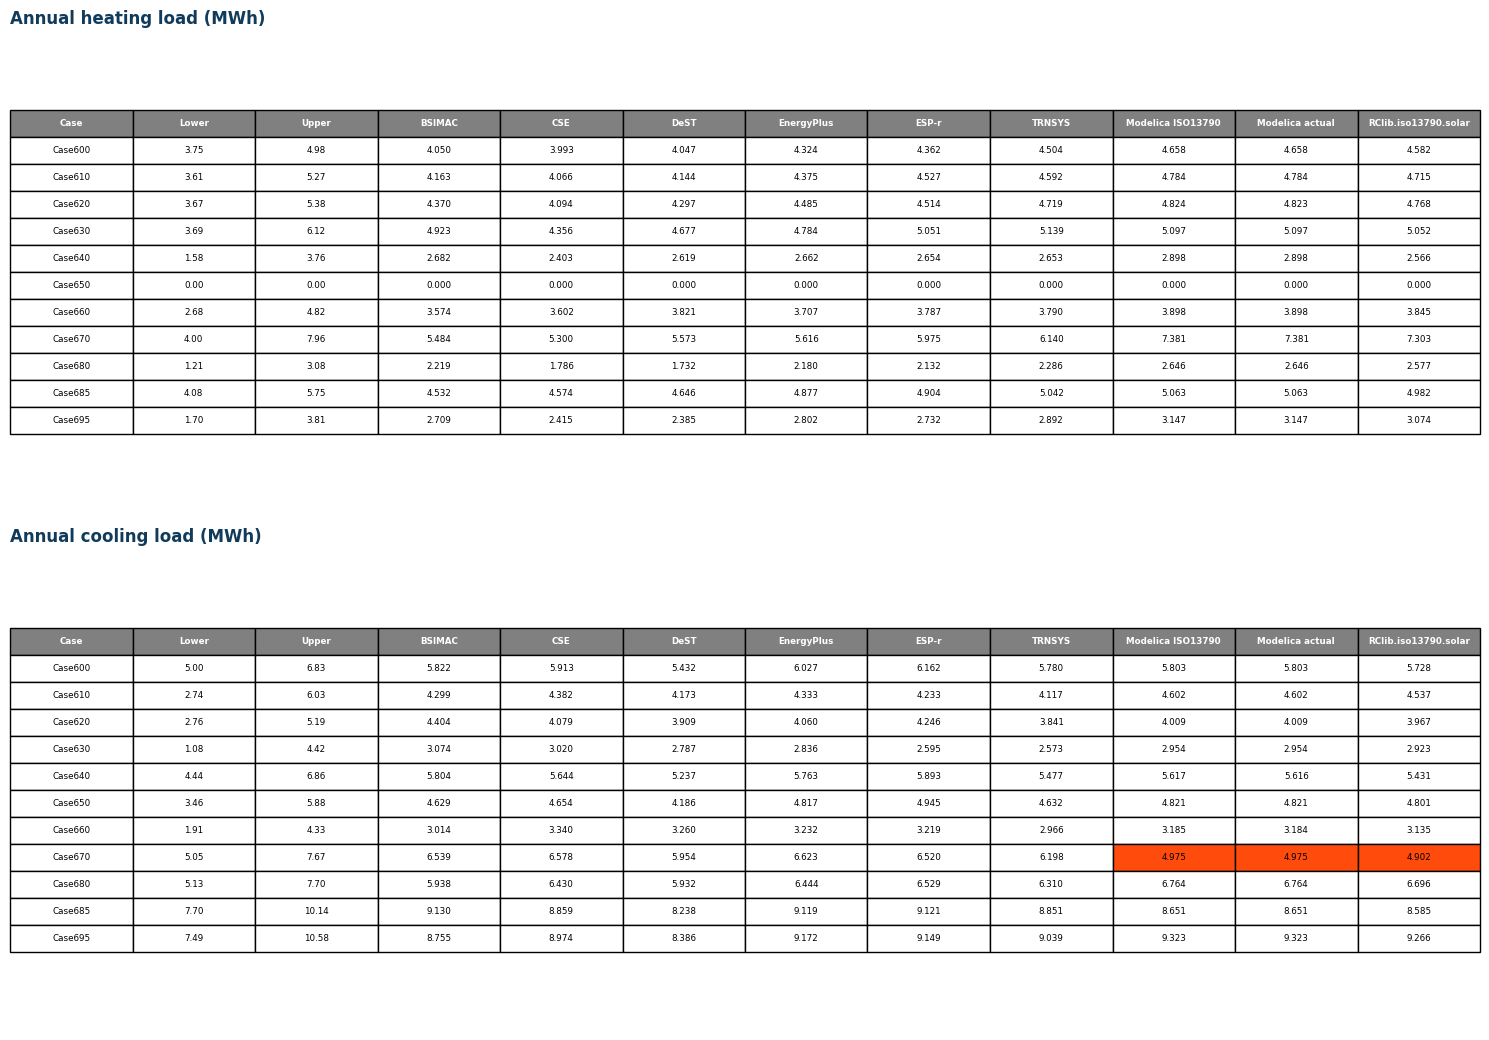

,case,metric,actual_modelica_MWh,rclib_iso_modelica_solar_MWh,actual_modelica_status
0,600,heating,4.657997,4.582236,PASS
1,610,heating,4.783806,4.714909,PASS
2,620,heating,4.823477,4.768045,PASS
3,630,heating,5.096715,5.052480,PASS
4,640,heating,2.898367,2.566110,PASS
5,650,heating,0.000000,0.000000,PASS
6,660,heating,3.898471,3.844761,PASS
7,670,heating,7.381270,7.302776,PASS
8,680,heating,2.646207,2.577225,PASS
9,685,heating,5.063028,4.982195,PASS


In [5]:
from bestest_iso_plot_ashrae140_annual_matrix import build_summary, draw_table
matrix = build_summary()
family_cases = ('600', '610', '620', '630', '640', '650', '660', '670', '680', '685', '695')
fig, axes = plt.subplots(2, 1, figsize=(15, 10.5))
draw_table(axes[0], 'heating', matrix, family_cases)
draw_table(axes[1], 'cooling', matrix, family_cases)
fig.tight_layout(); plt.show()
display(matrix[matrix.case.isin(family_cases)][['case', 'metric', 'actual_modelica_MWh', 'rclib_iso_modelica_solar_MWh', 'actual_modelica_status']])

## Annual ASHRAE 140 matrix

LBNL-style annual heating and cooling tables. Red cells are outside valid published acceptance bounds; native ISO is the formal Python result.

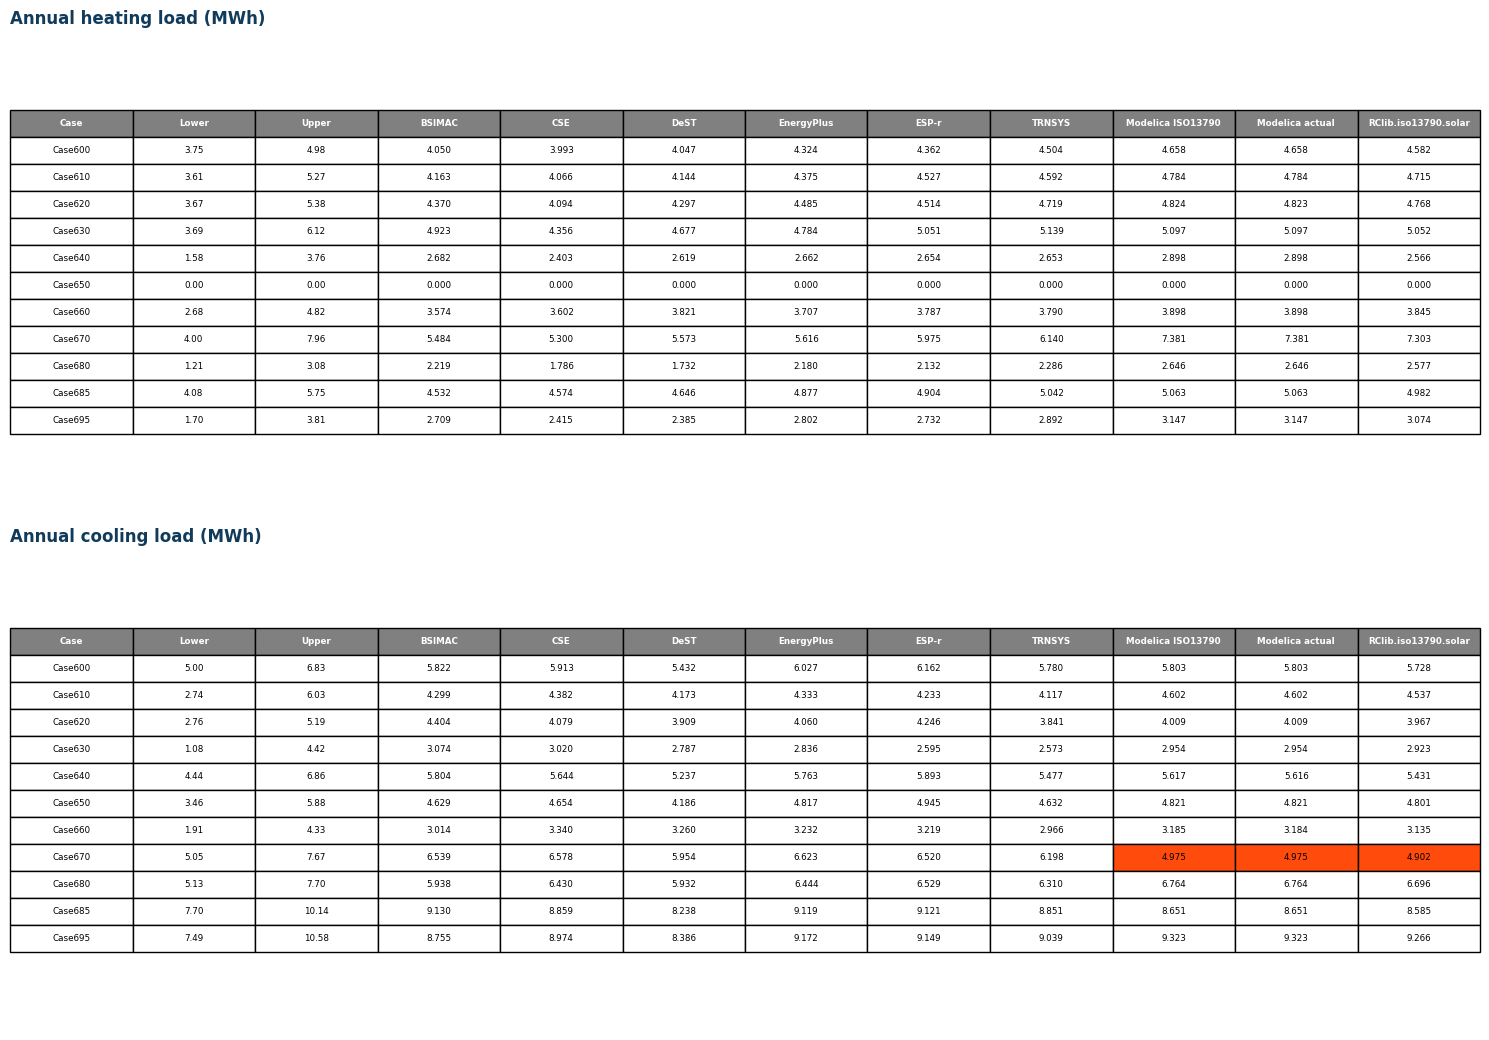

,case,metric,actual_modelica_MWh,rclib_iso_modelica_solar_MWh,actual_modelica_status
0,600,heating,4.657997,4.582236,PASS
1,610,heating,4.783806,4.714909,PASS
2,620,heating,4.823477,4.768045,PASS
3,630,heating,5.096715,5.052480,PASS
4,640,heating,2.898367,2.566110,PASS
5,650,heating,0.000000,0.000000,PASS
6,660,heating,3.898471,3.844761,PASS
7,670,heating,7.381270,7.302776,PASS
8,680,heating,2.646207,2.577225,PASS
9,685,heating,5.063028,4.982195,PASS


In [6]:
from bestest_iso_plot_ashrae140_annual_matrix import build_summary, draw_table
matrix = build_summary()
family_cases = ('600', '610', '620', '630', '640', '650', '660', '670', '680', '685', '695')
fig, axes = plt.subplots(2, 1, figsize=(15, 10.5))
draw_table(axes[0], 'heating', matrix, family_cases)
draw_table(axes[1], 'cooling', matrix, family_cases)
fig.tight_layout(); plt.show()
display(matrix[matrix.case.isin(family_cases)][['case', 'metric', 'actual_modelica_MWh', 'rclib_iso_modelica_solar_MWh', 'actual_modelica_status']])